## Cleaning
Multimodal models allow for good text-image matching, but in a general setting they can be bad at specific industry terms (e.g., "dress" vs "gown" vs "mini-dress").

This can be overcome by fine-tuning the model on a specific dataset like the H&M Personalized Fashion Racommendations Dataset. It contains aroung 105k images, each mapped to the corresponding text descriptions. Here I will analyze this dataset further and transform it into an appropriate form.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import random
from PIL import Image

In [2]:
df = pd.read_csv('../data/raw/articles.csv', dtype={'article_id': str}) # Force ID to be string because of zeros in the beginning 
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   article_id                    105542 non-null  str  
 1   product_code                  105542 non-null  int64
 2   prod_name                     105542 non-null  str  
 3   product_type_no               105542 non-null  int64
 4   product_type_name             105542 non-null  str  
 5   product_group_name            105542 non-null  str  
 6   graphical_appearance_no       105542 non-null  int64
 7   graphical_appearance_name     105542 non-null  str  
 8   colour_group_code             105542 non-null  int64
 9   colour_group_name             105542 non-null  str  
 10  perceived_colour_value_id     105542 non-null  int64
 11  perceived_colour_value_name   105542 non-null  str  
 12  perceived_colour_master_id    105542 non-null  int64
 13  perceived_colour_master_n

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


The dataset has some null text descriptions:

In [3]:
df = df.dropna()

The `article_id` column maps to an image of the form `%article_id%.jpg`. Kaggle specifies, that not all `article_id` have a corresponding image. An id must consist of 10 digits, where the first 3 digits map to the folder, where the image is located:

In [4]:
df['article_id'].apply(lambda x: len(x)).value_counts()

article_id
10    105126
Name: count, dtype: int64

In [5]:
all_image_files = set(p.name for p in Path('../data/images').rglob('*.jpg'))
print(f"Found {len(all_image_files)} images.")

df['file_name'] = df['article_id'].apply(lambda x: f"{x}.jpg")
df['exists'] = df['file_name'].isin(all_image_files)
df = df[df['exists']].copy()

def get_image_path(file_name):
    subfolder = file_name[:3]
    return str(Path('data/images') / subfolder / file_name)
    
df['image_path'] = df['file_name'].apply(get_image_path)

print(f"{len(df)} valid images.")

Found 105100 images.
104696 valid images.


### Transformation

I will compress textual information into captions of the form `[LABEL][DESC]`, where `[LABEL]` is constructed as `color` + `product_type_name` and the `[DESC]` is simply `detail_desc`. This form is determined by observations of CLIP's positional bias. Namely, CLIP's encoder prioritizes first-mentioned objects in captions[[1](https://arxiv.org/abs/2502.19842v2)] and has the effective length of 20 tokens[[2](https://arxiv.org/abs/2403.15378v1)], despite being able to process 77 tokens. 
 
For neural search, queries like "Black Shoes" are expected and so they must instanly navigate to the correct neighborhood of the representation manifold, but that would be harder for a model, that saw only descriptions during training, as the semantic structures are different. Some `detail_desc` also do not include color, so this schema gives additional information about the image. However, many `detail_desc`s will include `product_type_name`.

Choosing `[LABEL][DESC]` ordering leads to the two side effects.

1. The signal for `product_type_name` is doubled, the name itself is always right at the beginning;
2. the dataset naturally contains many items with identical `color` + `product_type_name` pairs.

Thus, the first few words will have high predictive power. 

This creates the possibility for shortcut learning. I will use dropout on captions to address this. 

Now it's only important to decide, which color column to use, this dataset has two: `colour_group_name` and `percieved_colour_value_name`, the former is more diverse:

In [6]:
len(df['colour_group_name'].value_counts()) - len(df['perceived_colour_value_name'].value_counts())

42

In [7]:
df['perceived_colour_value_name'].value_counts()

perceived_colour_value_name
Dark            42325
Dusty Light     22002
Light           15598
Medium Dusty    12573
Bright           6399
Medium           5668
Undefined         103
Unknown            28
Name: count, dtype: int64

This shows, that `perceived_colour_value_name` is not a color taxonomy; in fact, it's a lightness dimension. Hence, I will stick to `colour_group_name`. Let's investigate it.

In [8]:
df['colour_group_name'].value_counts()

colour_group_name
Black              22457
Dark Blue          12077
White               9462
Light Pink          5760
Grey                4462
Light Beige         3330
Blue                3298
Red                 3031
Light Blue          2997
Greenish Khaki      2757
Dark Grey           2715
Off White           2712
Beige               2700
Dark Red            2325
Dark Green          2087
Light Grey          2085
Pink                2047
Yellow              1636
Light Orange        1505
Yellowish Brown     1457
Gold                1354
Dark Beige          1077
Light Turquoise     1019
Light Yellow         978
Dark Orange          882
Green                809
Dark Pink            808
Orange               769
Other Pink           739
Silver               692
Light Green          679
Dark Yellow          571
Light Purple         546
Dark Turquoise       469
Turquoise            430
Dark Purple          311
Light Red            282
Greyish Beige        224
Other Yellow         224
Purple 

The "Unknown" and "Other" values are meaningless and should be discarded. 

In [9]:
df.loc[df['colour_group_name'] == 'Unknown', 'colour_group_name'] = ''
df.loc[df['colour_group_name'] == 'Other', 'colour_group_name'] = ''

Such labeling abnormalities suggest inspecting `product_type_name` closer.

In [10]:
print(len(df[df['product_type_name'] == 'Unknown']))
print(len(df[df['colour_group_name'] == 'Other']))

121
0


In [11]:
df.loc[df['product_type_name'] == 'Unknown', 'product_type_name'] = ''

In [12]:
df['product_type_name'].unique().tolist()

['Vest top',
 'Bra',
 'Underwear Tights',
 'Socks',
 'Leggings/Tights',
 'Sweater',
 'Top',
 'Trousers',
 'Hair clip',
 'Umbrella',
 'Pyjama jumpsuit/playsuit',
 'Bodysuit',
 'Hair string',
 '',
 'Hoodie',
 'Sleep Bag',
 'Hair/alice band',
 'Belt',
 'Boots',
 'Bikini top',
 'Swimwear bottom',
 'Underwear bottom',
 'Swimsuit',
 'Skirt',
 'T-shirt',
 'Dress',
 'Hat/beanie',
 'Kids Underwear top',
 'Shorts',
 'Shirt',
 'Cap/peaked',
 'Pyjama set',
 'Sneakers',
 'Sunglasses',
 'Cardigan',
 'Gloves',
 'Earring',
 'Bag',
 'Blazer',
 'Other shoe',
 'Jumpsuit/Playsuit',
 'Sandals',
 'Jacket',
 'Costumes',
 'Robe',
 'Scarf',
 'Coat',
 'Other accessories',
 'Polo shirt',
 'Slippers',
 'Night gown',
 'Alice band',
 'Straw hat',
 'Hat/brim',
 'Tailored Waistcoat',
 'Ballerinas',
 'Tie',
 'Necklace',
 'Pyjama bottom',
 'Felt hat',
 'Bracelet',
 'Blouse',
 'Outdoor overall',
 'Watch',
 'Underwear body',
 'Beanie',
 'Giftbox',
 'Sleeping sack',
 'Dungarees',
 'Outdoor trousers',
 'Wallet',
 'Swimwear

It seems that there's nothing else left for cleaning, so now we can concatenate into captions.

In [13]:
def create_caption(row):
    return f"{row['colour_group_name']} {row['product_type_name']}. {row['detail_desc']}".strip()

df['caption'] = df.apply(create_caption, axis=1)

Caption: Dark Grey Cardigan. Cardigan in a soft rib knit with a shawl collar, long sleeves and no buttons.
Path: data\images\046\0469682008.jpg


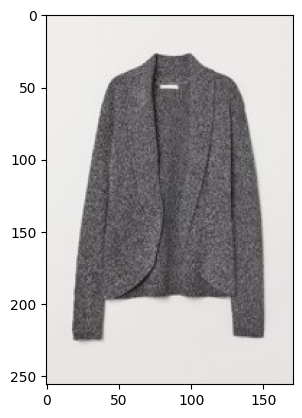

In [14]:
random_row = df.iloc[random.randint(0, len(df))]
print(f"Caption: {random_row['caption']}")
print(f"Path: {random_row['image_path']}")

try:
    img = Image.open(Path('..') / random_row['image_path'])
    plt.imshow(img)
    plt.show()
except FileNotFoundError:
    print('Image not found!')

In [15]:
cols = [
    'article_id', 
    'image_path', 
    'colour_group_name',
    'product_type_name',
    'detail_desc',
    'caption',        
]
df[cols].to_parquet('../data/dataset/articles.parquet', index=False)